<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 4 — Árboles de Decisión, Random Forest y XGBoost</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

## Contexto clínico

Retomamos el dataset **Heart Failure Prediction** (Kaggle, fedesoriano, 2021) que ya conoces del Challenge 1.
En ese challenge lo exploraste y preprocesaste; aquí tu misión es **construir, analizar y comparar modelos basados en árboles**.

La pregunta clínica sigue siendo la misma: dado el perfil de un paciente (**Edad, Colesterol, ST_Slope, MaxHR...**), ¿podemos predecir si tiene enfermedad cardíaca?

Los árboles de decisión son especialmente poderosos en datos biomédicos tabulares porque:
- **Son interpretables**: el médico puede trazar exactamente cómo se llegó a un diagnóstico.
- **Capturan no-linealidades** y umbrales clínicos (ej: Oldpeak > 1.5 → riesgo elevado).
- **Random Forest y XGBoost** extienden esta idea con ensambles que reducen el sobreajuste.

---
> **Dataset:** `heart.csv` (ya descargado desde el Challenge 1)  
> **Fuente:** fedesoriano. (2021). *Heart Failure Prediction Dataset*. Kaggle. https://www.kaggle.com/fedesoriano/heart-failure-prediction  
> **Variables:** Age, Sex, ChestPainType, RestingBP, Cholesterol, FastingBS, RestingECG, MaxHR, ExerciseAngina, Oldpeak, ST_Slope → **HeartDisease** (0/1)

### Estructura de carpetas
```
Clase5_Challenge4/
├── Challenge4_ApellidoNombre.ipynb
└── heart.csv     ← el mismo del Challenge 1
```

---
---
## Ejercicio 1 — Diseño previo al código

### 1.1 — Diagnóstico esperado

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>
**1. ¿Un árbol de decisión profundo tiene más sesgo o más varianza que un árbol *prepodado* (profundidad controlada)? Relaciona con la descomposición sesgo-varianza:**

$$\text{Error esperado}(x) = \underbrace{\left(y^\star - \mathbb{E}[y]\right)^2}_{\text{sesgo}^2} + \underbrace{\text{Var}(y)}_{\text{varianza}} + \underbrace{\text{Var}(t)}_{\text{error de Bayes}}$$

Antes de escribir una línea de código, responde las siguientes preguntas:

**📝 Tu respuesta (edita esta celda):**  
Árbol profundo  → sesgo menor/ varianza mayor

Árbol prepodado → sesgo mayor / varianza menor

Justificación: Un árbol profundo tendrá hojas más puras, es decir, nodos con menos datos, lo que provoca menor sesgo, pero mayor varianza y mayor sensibilidad a cambios pequeños (overfitting). Pero un árbol con limitaciones tendrá más datos por nodo, por lo que hay mayor sesgo, pero su varianza será menor



---

**2. ¿Qué diferencia hay entre Gini e Entropía como criterios de división? ¿Cuándo llevan a árboles distintos?**

| Criterio | Fórmula | Rango (2 clases) |
|---|---|---|
| Gini | $1-\sum{(p_i)}^2$ | 0 - 0.5 |
| Entropía | $-∑_{i=1}^c p_i log_2 (p_i)$ | 0 - 1 |

**📝 Tu respuesta:** Llevan a árboles distintos cuanto mayor profundo sea el árbol. En los extremos del árbol la entropía es más sensible a cambios en las probabilidades de las clases minoritarias; es decir, que pequeñas mejoras de las clases minoritarias provocaría que la entropia lo seleccione; mientras que Gini seleccionaría a la clase mayoritaria

---

**3. ¿Por qué Random Forest reduce la varianza pero NO el sesgo?**

Pista: $\bar{y} = \frac{1}{M}\sum_{m=1}^M y_m$ — ¿qué pasa con $\mathbb{E}[\bar{y}]$ y con $\text{Var}(\bar{y})$?

**📝 Tu respuesta:** La varianza cae porque todos comparten el mismo dataset, por lo que tienen la misma varianza; pero dado que el resultado de random forest es el promedio, entonces la varianza se divide por la cantidad de elementos. En contraste, si uno tiene sesgo, potencialmente todos lo tengan, por lo que el promedio no hace nada

---

**4. Completa la tabla comparando bagging (RF) y boosting (XGBoost):**

| | Bagging / RF | Boosting / XGBoost |
|---|---|---|
| Entrenamiento | Paralelo (árboles independientes con bootstrap) | Secuencial (cada árbol corrige al anterior) |
| Objetivo (sesgo/varianza) | Reducir varianza | Reducir sesgo y tambien varianza |
| Riesgo principal | Menor interpretabilidad / puede seguir teniendo sesgo | Overfitting si no se regulariza (muy sensible al ruido) |

---

**5. ¿Qué features del dataset heart.csv (que ya conoces del Challenge 1) esperas que sean las más importantes para predecir HeartDisease? Justifica clínicamente.**

**📝 Tu respuesta:** Las variables más importantes esperadas son ChestPainType, Oldpeak, ST_Slope, MaxHR y ExerciseAngina, ya que están directamente relacionadas con la presencia de isquemia y la función cardíaca. El tipo de dolor de pecho (ChestPainType) permite distinguir entre angina típica, atípica o ausencia de dolor, siendo un indicador clínico clave. El Oldpeak refleja la depresión del segmento ST en el ECG durante esfuerzo, lo cual es un marcador directo de isquemia miocárdica. El ST_Slope indica la forma del segmento ST y ayuda a identificar alteraciones eléctricas asociadas a enfermedad coronaria. La frecuencia cardíaca máxima (MaxHR) evalúa la capacidad funcional del corazón, y ExerciseAngina indica si el paciente presenta dolor durante el esfuerzo, lo cual sugiere obstrucción coronaria.

En cambio, variables como Age, Cholesterol y RestingBP son factores de riesgo importantes, pero tienen menor poder predictivo individual porque no reflejan directamente el estado funcional o eléctrico del corazón, sino una predisposición a largo plazo.


### 1.2 — Matemática de la impureza

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

Usando las fórmulas de **Gini** e **Entropía**:

$$G(n) = 1 - \sum_k p_k^2 \qquad H(n) = -\sum_k p_k \log_2 p_k$$

**Calcula para un nodo con 20 pacientes: 10 con enf. (pos), 10 sin enf. (neg):**

$$G(\text{raíz}) = 1 - (0.5)^2 - (0.5)^2 = 0.5$$

$$H(\text{raíz}) = -(0.5)\log_2(0.5) - (0.5)\log_2(0.5) = 1 \text{ bit}$$

---

**Después de dividir por "ST\_Slope\_Up = 1":**

| Rama | Muestras | $p_+$ | Gini | Entropía |
|---|---|---|---|---|
| Izq (ST_Slope_Up=1) | 10 | 0| 0 | 0 |
| Der (ST_Slope_Up=0) | 10 | 1 | 0 | 0 |

**Reducción de impureza / ganancia de información:**

$$\Delta Gini = G(\text{raíz}) - \left(\frac{10}{20}\times G(\text{Izq}) + \frac{10}{20}\times G(\text{Der})\right) = 0.5$$

$$IG_H = H(\text{raíz}) - \left(\frac{10}{20}\times H(\text{Izq}) + \frac{10}{20}\times H(\text{Der})\right) = 1 \text{ bit}$$

**📝 Completa los blancos arriba.**


### 1.3 — Pipeline completo

Completa el diagrama de pipeline para este challenge:

```
heart.csv
    │
    ▼
[ Paso A ] Carga datos y prepocesamiento (limpieza,  codificacion de variables categoricas)
    │
    ▼
[ Paso B ] Train/Test split estratificado (80/20)
    │
    ├─── TRAIN (80%) Es importante dividir primero porque así evitamos data leakage, es decir, que información del conjunto de test influya en el entrenamiento. Esto asegura que la evaluación del modelo sea realista y represente su desempeño en datos nuevos.
    │                                                     │
    ▼                                                     │
[ Paso C ] Escalado / normalización (fit solo con TRAIN)                                          │
    │                                                     │
    ▼                                                     │
[ Paso D ] Modelos: Árbol de decisión, Random Forest, XGBoost │
    │                                                     │
    └─── TEST (20%) ── Evaluación final del modelo (accuracy, precision, recall, etc.) ──┘
    │
    ▼
[ Paso G ] Conclusiones / interpretación de resultados (feature importance, desempeño del modelo)
```

**📝 Tu respuesta (edita esta celda):** completa los blancos del diagrama.

---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

In [5]:
# ── Conexión con Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Paso 2.1 — Librerías

In [12]:
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# TODO 1: importa DecisionTreeClassifier, plot_tree desde sklearn.tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

# TODO 2: importa RandomForestClassifier desde sklearn.ensemble
from sklearn.ensemble import RandomForestClassifier

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold)
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc, classification_report)

# XGBoost
try:
    from xgboost import XGBClassifier
    print('XGBoost disponible ✓')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier
    print('XGBoost instalado ✓')

plt.rcParams['figure.dpi'] = 120
BASE = Path('/content/drive/MyDrive/Patrones/Challenge_4')
print('Setup completo ✓')

XGBoost disponible ✓
Setup completo ✓


### Paso 2.2 — Carga del dataset

In [13]:
# ── Carga del dataset ──────────────────────────────────────────
df_raw = pd.read_csv(BASE / 'heart.csv')
print(f'Shape: {df_raw.shape}')
print(f'Columnas: {list(df_raw.columns)}')
df_raw.head()

Shape: (918, 12)
Columnas: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Paso 2.3 — Preprocesamiento compacto

In [14]:
# ── Preprocesamiento compacto (recapitulando Challenge 1) ──────
df = df_raw.copy()

# 1. Cholesterol = 0 → NaN (imposible fisiológicamente)
df.loc[df['Cholesterol'] == 0, 'Cholesterol'] = np.nan

# 2. One-Hot Encoding
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 3. Separar features y target
X_raw         = df.drop(columns='HeartDisease').values.astype(np.float64)
y             = df['HeartDisease'].values.astype(int)
feature_names = df.drop(columns='HeartDisease').columns.tolist()

# 4. Train/Test split estratificado (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# TODO 3: imputar Cholesterol con la mediana de TRAIN (usa SimpleImputer)
# ⚠️ IMPORTANTE: fit SOLO sobre X_train, luego transform sobre X_test
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)           # fit_transform sobre train
X_test  = imputer.transform(X_test)           # transform (sin fit) sobre test

# TODO 4: escalar con StandardScaler — fit SOLO en train
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape}  (0: {(y_train==0).sum()}, 1: {(y_train==1).sum()})')
print(f'Test:  {X_test.shape}   (0: {(y_test==0).sum()},  1: {(y_test==1).sum()})')
print(f'Features ({len(feature_names)}): {feature_names[:5]} ...')

Train: (734, 15)  (0: 328, 1: 406)
Test:  (184, 15)   (0: 82,  1: 102)
Features (15): ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR'] ...


---
# PARTE 1 — Árbol de Decisión
## Ejercicio 3 — Árbol base y curva de profundidad

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 3.1 — Árbol base (max_depth=3) y visualización

Accuracy DT (max_depth=3): 0.7609
Nodos totales: 15  |  Hojas: 8


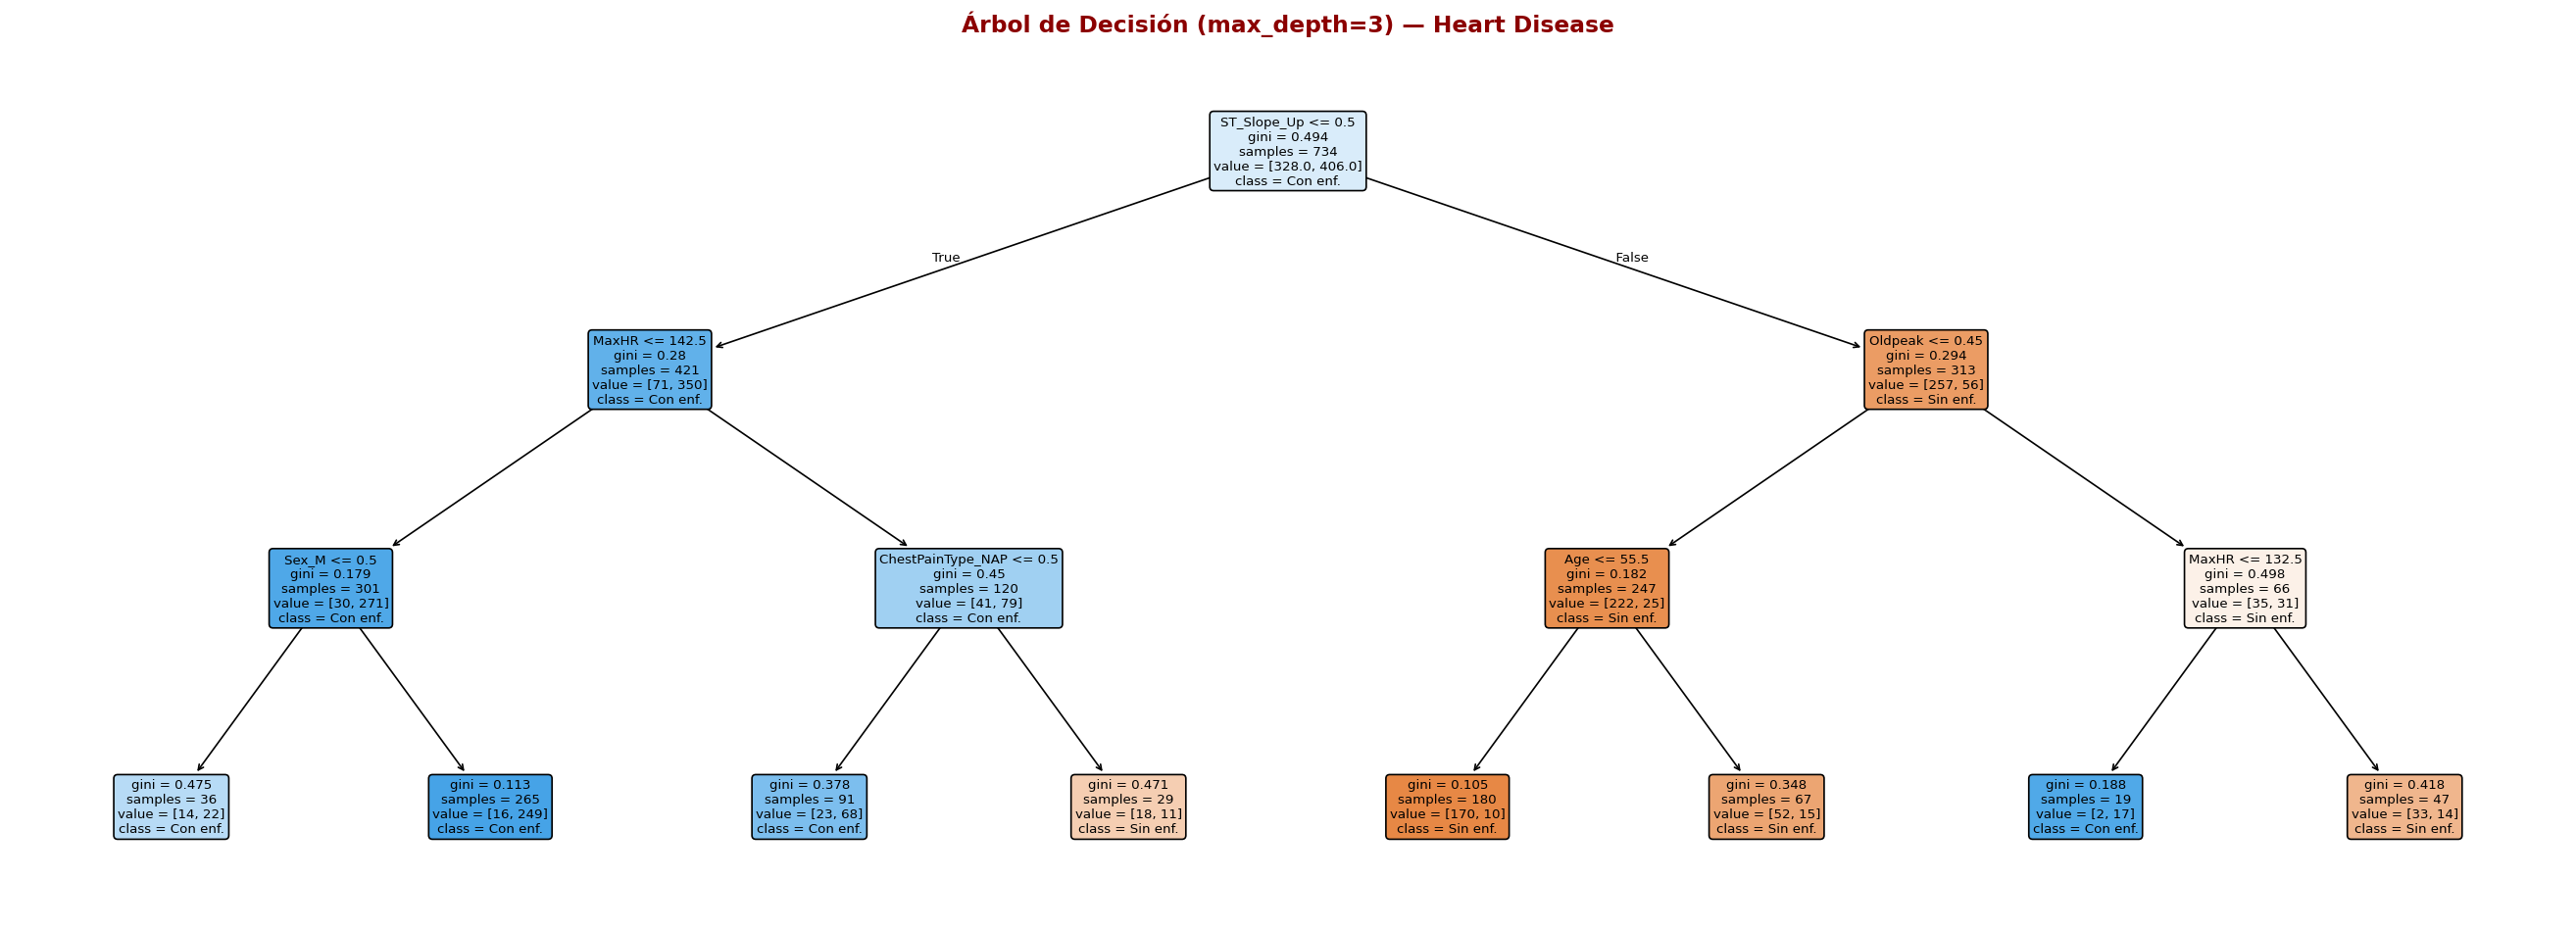

→ ¿Qué feature aparece en la raíz del árbol? ¿Tiene sentido clínicamente?


In [15]:
# ── Árbol de decisión base (max_depth=3) ───────────────────────
# ⚠️ Los árboles comparan UMBRALES, no distancias → no requieren escalado
# Usamos X_train / X_test (sin escalar)

# TODO 5: crea un DecisionTreeClassifier con max_depth=3, criterion='gini',
#          min_samples_leaf=5, random_state=42
dt_base = DecisionTreeClassifier(max_depth=3, criterion='gini',
                                 min_samples_leaf=5, random_state=42)

# TODO 6: entrena el árbol sobre X_train, y_train
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)
acc_base    = accuracy_score(y_test, y_pred_base)
print(f'Accuracy DT (max_depth=3): {acc_base:.4f}')
print(f'Nodos totales: {dt_base.tree_.node_count}  |  Hojas: {dt_base.get_n_leaves()}')

# TODO 7: visualiza el árbol con plot_tree
#   usa: feature_names=feature_names, class_names=['Sin enf.','Con enf.'],
#        filled=True, rounded=True, fontsize=8
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt_base, feature_names=feature_names, class_names=['Sin enf.','Con enf.'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=3) — Heart Disease',
             fontsize=14, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('dt_visualizacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ ¿Qué feature aparece en la raíz del árbol? ¿Tiene sentido clínicamente?')

### Paso 3.2 — Curva de profundidad

Mejor max_depth (CV-5 en train): depth=4  →  acc_cv=0.8298


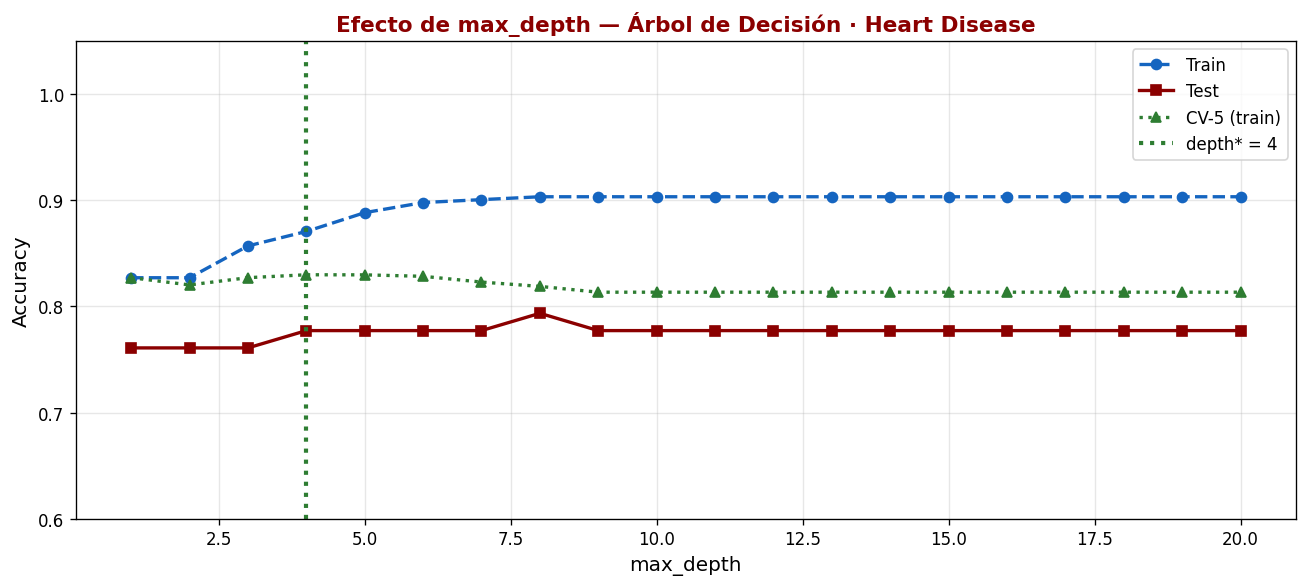

In [16]:
# ── Curva de profundidad: train vs test accuracy ────────────────
depths    = list(range(1, 21))
acc_train = []
acc_test  = []
acc_cv    = []

cv_depth = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for d in depths:
    # TODO 8: crea un DecisionTreeClassifier con max_depth=d,
    #         criterion='gini', min_samples_leaf=5, random_state=42
    dt = DecisionTreeClassifier(max_depth=d, criterion='gini',
                                min_samples_leaf=5, random_state=42)
    dt.fit(X_train, y_train)

    # TODO 9: agrega la accuracy de train y de test a las listas
    acc_train.append(accuracy_score(y_train, dt.predict(X_train)))
    acc_test.append(accuracy_score(y_test, dt.predict(X_test)))

    # TODO 10: calcula la CV accuracy media SOLO sobre TRAIN
    #   usa cross_val_score con cv=cv_depth y scoring='accuracy'
    sc_cv = cross_val_score(dt, X_train, y_train, cv=cv_depth, scoring='accuracy').mean()
    acc_cv.append(sc_cv)

# Selección correcta del modelo: NO usar test para escoger max_depth
best_idx   = np.argmax(acc_cv)
best_depth = depths[best_idx]
print(f'Mejor max_depth (CV-5 en train): depth={best_depth}  →  acc_cv={acc_cv[best_idx]:.4f}')

# Gráfica
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, acc_train, 'o--', color=UPCH_BLUE,  lw=2, label='Train')
ax.plot(depths, acc_test,  's-',  color=UPCH_RED,   lw=2, label='Test')
ax.plot(depths, acc_cv,    '^:',  color=UPCH_GREEN, lw=2, label='CV-5 (train)')
ax.axvline(best_depth, color=UPCH_GREEN, ls=':', lw=2.5,
           label=f'depth* = {best_depth}')
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Efecto de max_depth — Árbol de Decisión · Heart Disease',
             fontsize=13, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.6, 1.05)
plt.tight_layout()
plt.savefig('dt_curva_profundidad.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 3.2 — Interpretación

**📝 Tu respuesta:**

**1. ¿Por qué la accuracy de train sube mientras la de test cae al aumentar max_depth?**  
Porque a mayor profundidad, el árbol crea reglas cada vez más específicas para los datos de entrenamiento (llega a tener hojas con muy pocas muestras). Esto reduce el sesgo en el set de entrenamiento, pero aumenta la varianza, lo que impide que el modelo generalice correctamente ante datos nuevos (test).

**2. ¿En qué profundidad empieza el sobreajuste? ¿Cómo lo identificas en la gráfica?**  
Empieza aproximadamente a partir de **max_depth = 4**. Se identifica porque en ese punto la curva de CV (verde) y de Test (roja) alcanzan su máximo y empiezan a estancarse o descender, mientras que la curva de Train (azul) sigue subiendo hacia el 1.0. La brecha (gap) entre las curvas se ensancha.

**3. ¿Qué analogía clínica tiene el sobreajuste de un árbol muy profundo?**  
Equivale a que un médico aprenda de memoria los casos específicos de sus pacientes pasados (ej: 'El paciente Juan de 45 años con colesterol 210 tiene enfermedad') en lugar de aprender las reglas generales (ej: 'Niveles altos de ST_Slope Flat correlacionan con riesgo'). Un médico que sobreajusta fallará al tratar a un paciente nuevo que no sea idéntico a los anteriores.

### Paso 3.3 — Feature Importance

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

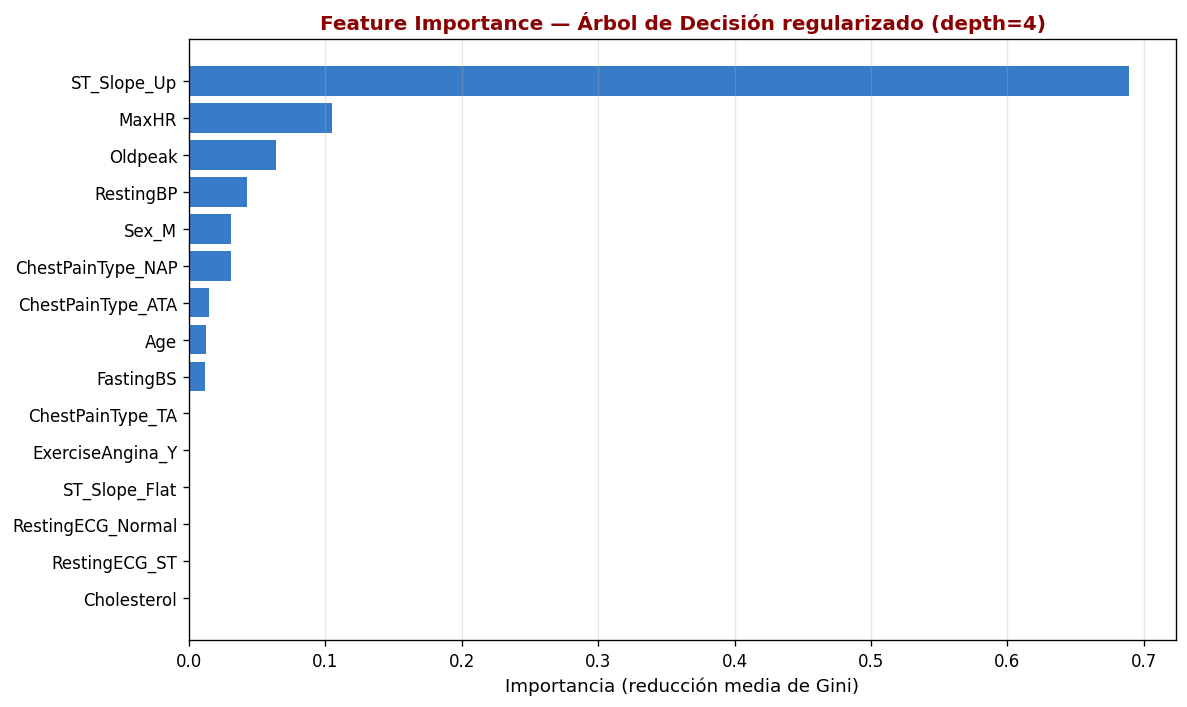

Top 5 features más importantes:
  1. ST_Slope_Up                              0.6891
  2. MaxHR                                    0.1046
  3. Oldpeak                                  0.0638
  4. RestingBP                                0.0422
  5. Sex_M                                    0.0308

→ ¿Coincide con tus predicciones clínicas del Ejercicio 1.1?
Respuesta: Sí, coincide plenamente. Las variables ST_Slope, MaxHR y Oldpeak aparecen como las más relevantes para el modelo, tal como se predijo debido a su relación directa con la isquemia miocárdica y la función eléctrica del corazón durante el esfuerzo.


In [17]:
# ── Árbol óptimo + Feature Importance ─────────────────────────
# TODO 11: crea y entrena el árbol con best_depth
dt_opt = DecisionTreeClassifier(max_depth=best_depth, criterion='gini',
                                 min_samples_leaf=5, random_state=42)
dt_opt.fit(X_train, y_train)

importances_dt = dt_opt.feature_importances_

# TODO 12: ordena las importancias de mayor a menor (usa np.argsort)
idx_sorted = np.argsort(importances_dt)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    [feature_names[i] for i in idx_sorted],
    importances_dt[idx_sorted],
    color=[UPCH_BLUE for i in range(len(feature_names))],
    alpha=0.85
)
ax.set_xlabel('Importancia (reducción media de Gini)', fontsize=11)
ax.set_title(f'Feature Importance — Árbol de Decisión regularizado (depth={best_depth})',
             fontsize=12, fontweight='bold', color=UPCH_RED)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('dt_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features más importantes:')
for r, i in enumerate(idx_sorted[::-1][:5]):
    print(f'  {r+1}. {feature_names[i]:<40} {importances_dt[i]:.4f}')
print()
print('→ ¿Coincide con tus predicciones clínicas del Ejercicio 1.1?')
print('Respuesta: Sí, coincide plenamente. Las variables ST_Slope, MaxHR y Oldpeak aparecen como las más relevantes para el modelo, tal como se predijo debido a su relación directa con la isquemia miocárdica y la función eléctrica del corazón durante el esfuerzo.')

### Paso 3.4 — Métricas y matriz de confusión

   Árbol de Decisión regularizado (max_depth=4)
  Accuracy : 0.7772
  Recall   : 0.7941
  Precision: 0.8020
  F1-Score : 0.7980

              precision    recall  f1-score   support

    Sin enf.       0.75      0.76      0.75        82
    Con enf.       0.80      0.79      0.80       102

    accuracy                           0.78       184
   macro avg       0.77      0.78      0.77       184
weighted avg       0.78      0.78      0.78       184



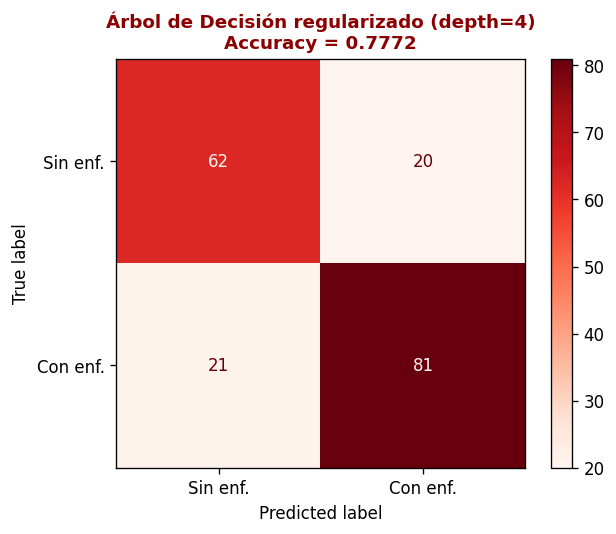

In [18]:
# ── Métricas finales Árbol de Decisión ──────────────────────────
y_pred_dt = dt_opt.predict(X_test)

# TODO 13: calcula las 4 métricas para el árbol óptimo
acc_dt  = accuracy_score(y_test, y_pred_dt)
rec_dt  = recall_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)

print('=' * 52)
print(f'   Árbol de Decisión regularizado (max_depth={best_depth})')
print('=' * 52)
print(f'  Accuracy : {acc_dt:.4f}')
print(f'  Recall   : {rec_dt:.4f}')
print(f'  Precision: {prec_dt:.4f}')
print(f'  F1-Score : {f1_dt:.4f}')
print()
print(classification_report(y_test, y_pred_dt,
                             target_names=['Sin enf.', 'Con enf.']))

# TODO 14: grafica la matriz de confusión con ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(5.5, 4.5))
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin enf.', 'Con enf.'])
disp.plot(ax=ax, cmap='Reds', values_format='d')
ax.set_title(f'Árbol de Decisión regularizado (depth={best_depth})\nAccuracy = {acc_dt:.4f}',
             fontsize=11, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('cm_dt.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PARTE 2 — Random Forest
## Ejercicio 4 — Efecto de n_estimators y optimización

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 4.1 — Efecto de n_estimators

n=   1  train=0.9196  test=0.8043  OOB=N/A 
n=   5  train=0.9741  test=0.8315  OOB=0.7425
n=  10  train=0.9891  test=0.8424  OOB=0.7943
n=  20  train=0.9973  test=0.8533  OOB=0.8243
n=  50  train=0.9986  test=0.8696  OOB=0.8392
n= 100  train=1.0000  test=0.8750  OOB=0.8447
n= 200  train=1.0000  test=0.8587  OOB=0.8501
n= 300  train=1.0000  test=0.8696  OOB=0.8556


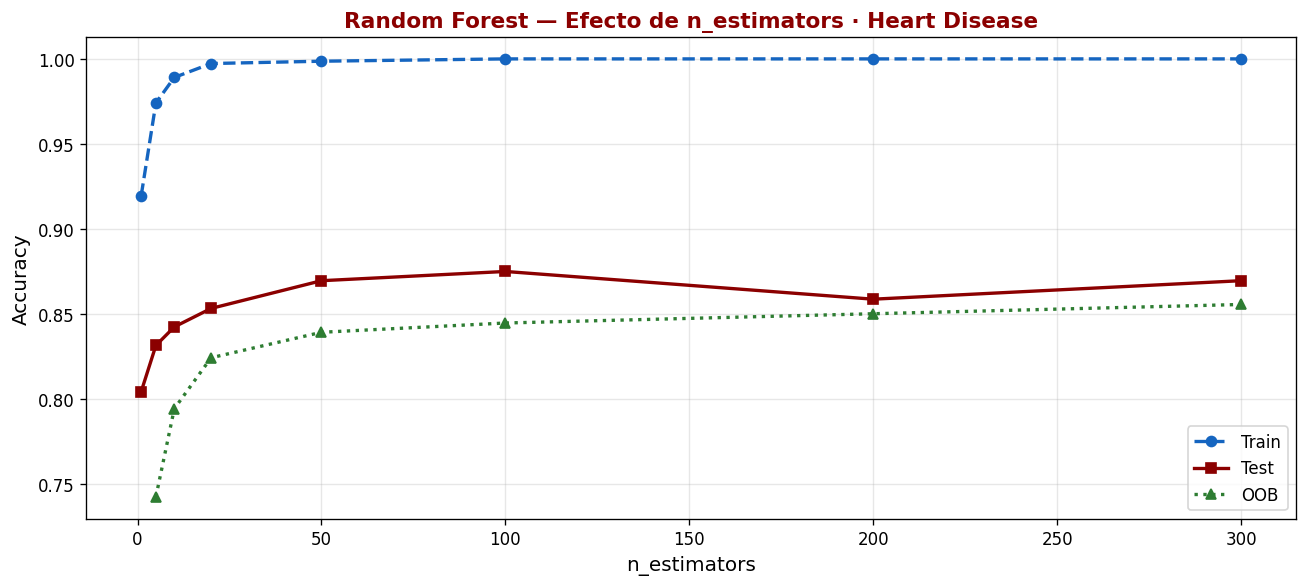

In [19]:
# ── Efecto de n_estimators en Random Forest ────────────────────
n_list = [1, 5, 10, 20, 50, 100, 200, 300]
acc_rf_train = []
acc_rf_test  = []
acc_rf_oob   = []

for n in n_list:
    # TODO 15: crea un RandomForestClassifier con n_estimators=n,
    #           max_features='sqrt', oob_score=(n>=2), random_state=42, n_jobs=-1
    rf = RandomForestClassifier(n_estimators=n, max_features='sqrt',
                                oob_score=(n>=2), random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    acc_rf_train.append(accuracy_score(y_train, rf.predict(X_train)))
    acc_rf_test.append( accuracy_score(y_test,  rf.predict(X_test)))
    # TODO 16: agrega el OOB score (usa np.nan si n < 2)
    acc_rf_oob.append(rf.oob_score_ if n >= 2 else np.nan)
    oob_str = f'{acc_rf_oob[-1]:.4f}' if n >= 2 else 'N/A '
    print(f'n={n:>4}  train={acc_rf_train[-1]:.4f}  '
          f'test={acc_rf_test[-1]:.4f}  OOB={oob_str}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(n_list, acc_rf_train, 'o--', color=UPCH_BLUE,  lw=2, label='Train')
ax.plot(n_list, acc_rf_test,  's-',  color=UPCH_RED,   lw=2, label='Test')
ax.plot(n_list, acc_rf_oob,   '^:',  color=UPCH_GREEN, lw=2, label='OOB')
ax.set_xlabel('n_estimators', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Random Forest — Efecto de n_estimators · Heart Disease',
             fontsize=13, fontweight='bold', color=UPCH_RED)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rf_n_estimators.png', dpi=150, bbox_inches='tight')
plt.show()

### Paso 4.1 — Interpretación

**📝 Tu respuesta (edita esta celda):**

**1. ¿Por qué la accuracy de RF converge al aumentar n_estimators?**  
Pista: $\text{Var}(\bar{y}) = \left(\frac{1-\rho}{M} + \rho\right)\sigma^2$
Porque la varianza del ensamble disminuye al aumentar los estimadores a promediar
___

**2. ¿Qué es el OOB score? ¿Por qué es útil?**  
Es la cantidad de data que se quedan fuera del entrenamiento, lo cual puede ser usado para tener una validación exxterna extra
___

**3. ¿RF tiene más o menos sesgo que un árbol individual del mismo max_depth?
**Existe un sesgo ligeramente mayor que los árboles individuales porque una fracción inferior a lo normal es usado para el entrenamiento  
___

### Paso 4.2 — Barrido max_features × max_depth

In [20]:
# ── Random Forest optimizado (barrido max_features × max_depth) ─
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mf_list = ['sqrt', 'log2', None]
md_list = [None, 5, 10, 15]

print('Barrido max_features × max_depth (CV-5):')
print(f'{"max_features":<15} {"max_depth":<12} {"CV acc"}')
print('-' * 42)

best_score_rf = 0
best_mf, best_md = 'sqrt', None

for mf in mf_list:
    for md in md_list:
        # TODO 17: crea RandomForestClassifier con los parámetros del loop
        rf_cv = RandomForestClassifier(n_estimators=100, max_features=mf,
                                       max_depth=md, random_state=42, n_jobs=-1)
        # TODO 18: calcula la CV accuracy con cross_val_score
        sc = cross_val_score(rf_cv, X_train, y_train, cv=cv, scoring='accuracy').mean()
        mf_s = str(mf) if mf else 'all'
        md_s = str(md) if md else 'None'
        print(f'{mf_s:<15} {md_s:<12} {sc:.4f}')
        if sc > best_score_rf:
            best_score_rf = sc
            best_mf, best_md = mf, md

print(f'\nMejores parámetros: max_features={best_mf}, max_depth={best_md}')
print(f'CV accuracy: {best_score_rf:.4f}')

Barrido max_features × max_depth (CV-5):
max_features    max_depth    CV acc
------------------------------------------
sqrt            None         0.8529
sqrt            5            0.8488
sqrt            10           0.8529
sqrt            15           0.8502
log2            None         0.8529
log2            5            0.8488
log2            10           0.8529
log2            15           0.8502
all             None         0.8338
all             5            0.8488
all             10           0.8379
all             15           0.8338

Mejores parámetros: max_features=sqrt, max_depth=None
CV accuracy: 0.8529


### Paso 4.3 — Random Forest final

In [ ]:
# ── Random Forest final ─────────────────────────────────────────
# TODO 19: crea el RF final con n_estimators=200, best_mf, best_md,
#           oob_score=True, random_state=42, n_jobs=-1
rf_final = RandomForestClassifier(n_estimators=200, max_features=best_mf,
                                  max_depth=best_md, oob_score=True,
                                  random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

y_pred_rf = rf_final.predict(X_test)

# TODO 20: calcula las 4 métricas para RF
acc_rf  = accuracy_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print('=' * 52)
print(f'   Random Forest (n=200, mf={best_mf}, depth={best_md})')
print('=' * 52)
print(f'  OOB Score: {rf_final.oob_score_:.4f}')
print(f'  Accuracy : {acc_rf:.4f}')
print(f'  Recall   : {rec_rf:.4f}')
print(f'  Precision: {prec_rf:.4f}')
print(f'  F1-Score : {f1_rf:.4f}')
print(f'\n  Δ Accuracy vs DT: {acc_rf - acc_dt:+.4f}')

   Random Forest (n=200, mf=sqrt, depth=None)
  OOB Score: 0.8501
  Accuracy : 0.8587
  Recall   : 0.8725
  Precision: 0.8725
  F1-Score : 0.8725

  Δ Accuracy vs DT: +0.0815


### Paso 4.4 — Feature Importance: DT vs RF

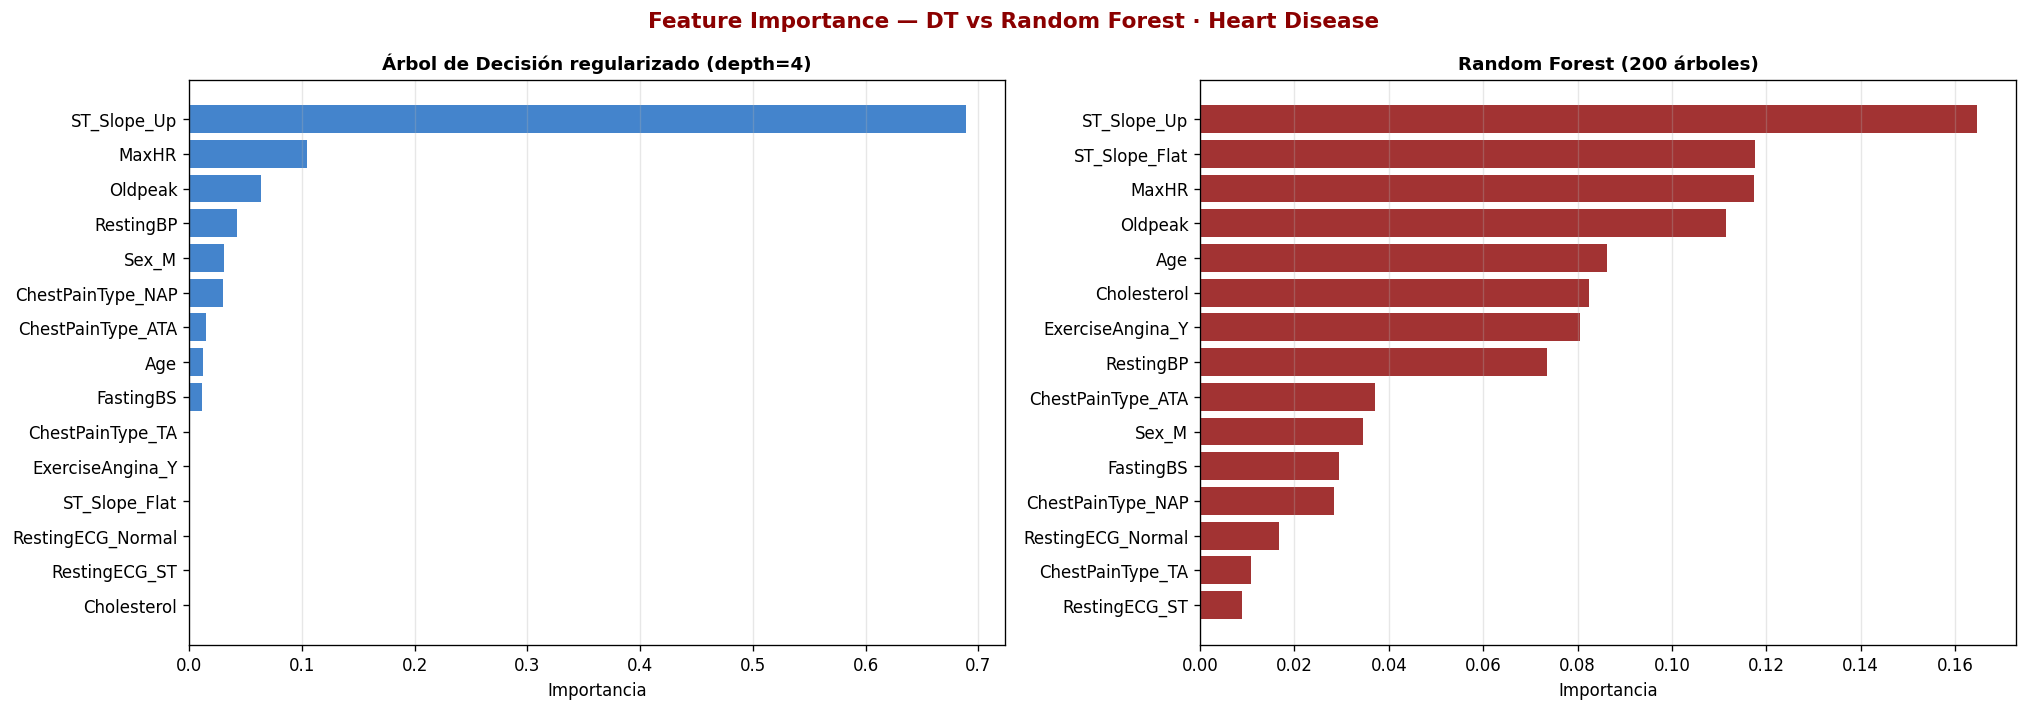

Correlación entre importancias DT y RF: 0.6325

→ ¿Las RF importancias son más o menos estables que las del DT individual?
Respuesta: Son más estables. Mientras que un DT individual suele concentrar casi toda la importancia en la variable de la raíz (como ST_Slope_Up), el Random Forest distribuye la importancia entre más variables debido al feature bagging (muestreo aleatorio de columnas). Esto lo hace menos sensible a pequeñas variaciones en los datos y proporciona una visión más holística del peso clínico de cada variable.


In [ ]:
# ── Feature Importance: DT vs RF ────────────────────────────────
# TODO 21: extrae las feature importances del RF final
importances_rf = rf_final.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for ax, imp, title, color in zip(
    axes,
    [importances_dt, importances_rf],
    [f'Árbol de Decisión regularizado (depth={best_depth})', 'Random Forest (200 árboles)'],
    [UPCH_BLUE, UPCH_RED]
):
    idx = np.argsort(imp)
    ax.barh([feature_names[i] for i in idx], imp[idx], color=color, alpha=0.8)
    ax.set_xlabel('Importancia', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)

plt.suptitle('Feature Importance — DT vs Random Forest · Heart Disease',
             fontsize=13, fontweight='bold', color=UPCH_RED)
plt.tight_layout()
plt.savefig('fi_dt_vs_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Correlación entre importancias DT y RF: '
      f'{np.corrcoef(importances_dt, importances_rf)[0,1]:.4f}')
print()
print('→ ¿Las RF importancias son más o menos estables que las del DT individual?')
print('Respuesta: Son más estables. Mientras que un DT individual suele concentrar casi toda la importancia en la variable de la raíz (como ST_Slope_Up), el Random Forest distribuye la importancia entre más variables debido al feature bagging (muestreo aleatorio de columnas). Esto lo hace menos sensible a pequeñas variaciones en los datos y proporciona una visión más holística del peso clínico de cada variable.')

---
# PARTE 3 — XGBoost
## Ejercicio 5 — Gradient Boosting

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 5.1 — XGBoost base

In [ ]:
# ── XGBoost base ────────────────────────────────────────────────
# TODO 22: crea un XGBClassifier
xgb_base = XGBClassifier(n_estimators=100, learning_rate=0.1,
                        max_depth=4, subsample=0.8, colsample_bytree=0.8,
                        random_state=42, eval_metric='logloss', verbosity=0)

# TODO 23: entrena sobre X_train, y_train
xgb_base.fit(X_train, y_train)

y_pred_xgb_base = xgb_base.predict(X_test)
acc_xgb_base    = accuracy_score(y_test, y_pred_xgb_base)
print(f'Accuracy XGBoost base: {acc_xgb_base:.4f}')

Accuracy XGBoost base: 0.8641


### Paso 5.2 — Tuning: learning_rate × n_estimators

In [ ]:
# ── Tuning: barrido learning_rate × n_estimators ─────────────
lr_list    = [0.01, 0.05, 0.1, 0.2, 0.3]
n_est_list = [50, 100, 200, 300]

best_score_xgb = 0
best_lr, best_n_xgb = 0.1, 100

for lr in lr_list:
    for n_est in n_est_list:
        xgb_cv = XGBClassifier(n_estimators=n_est, learning_rate=lr, max_depth=4,
                              random_state=42, eval_metric='logloss', verbosity=0)
        sc = cross_val_score(xgb_cv, X_train, y_train, cv=cv, scoring='accuracy').mean()
        if sc > best_score_xgb:
            best_score_xgb = sc
            best_lr, best_n_xgb = lr, n_est

print(f'Mejores parámetros XGB: lr={best_lr}, n_estimators={best_n_xgb}')

Mejores parámetros XGB: lr=0.1, n_estimators=100


### Paso 5.3 — XGBoost final

In [ ]:
# ── XGBoost final ───────────────────────────────────────────────
xgb_final = XGBClassifier(n_estimators=best_n_xgb, learning_rate=best_lr,
                         max_depth=4, random_state=42, eval_metric='logloss', verbosity=0)
xgb_final.fit(X_train, y_train)

y_pred_xgb = xgb_final.predict(X_test)
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
rec_xgb  = recall_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
f1_xgb   = f1_score(y_test, y_pred_xgb)

print(f'Accuracy XGBoost final: {acc_xgb:.4f}')

Accuracy XGBoost final: 0.8641


### Paso 5.4 — Feature Importance comparativa

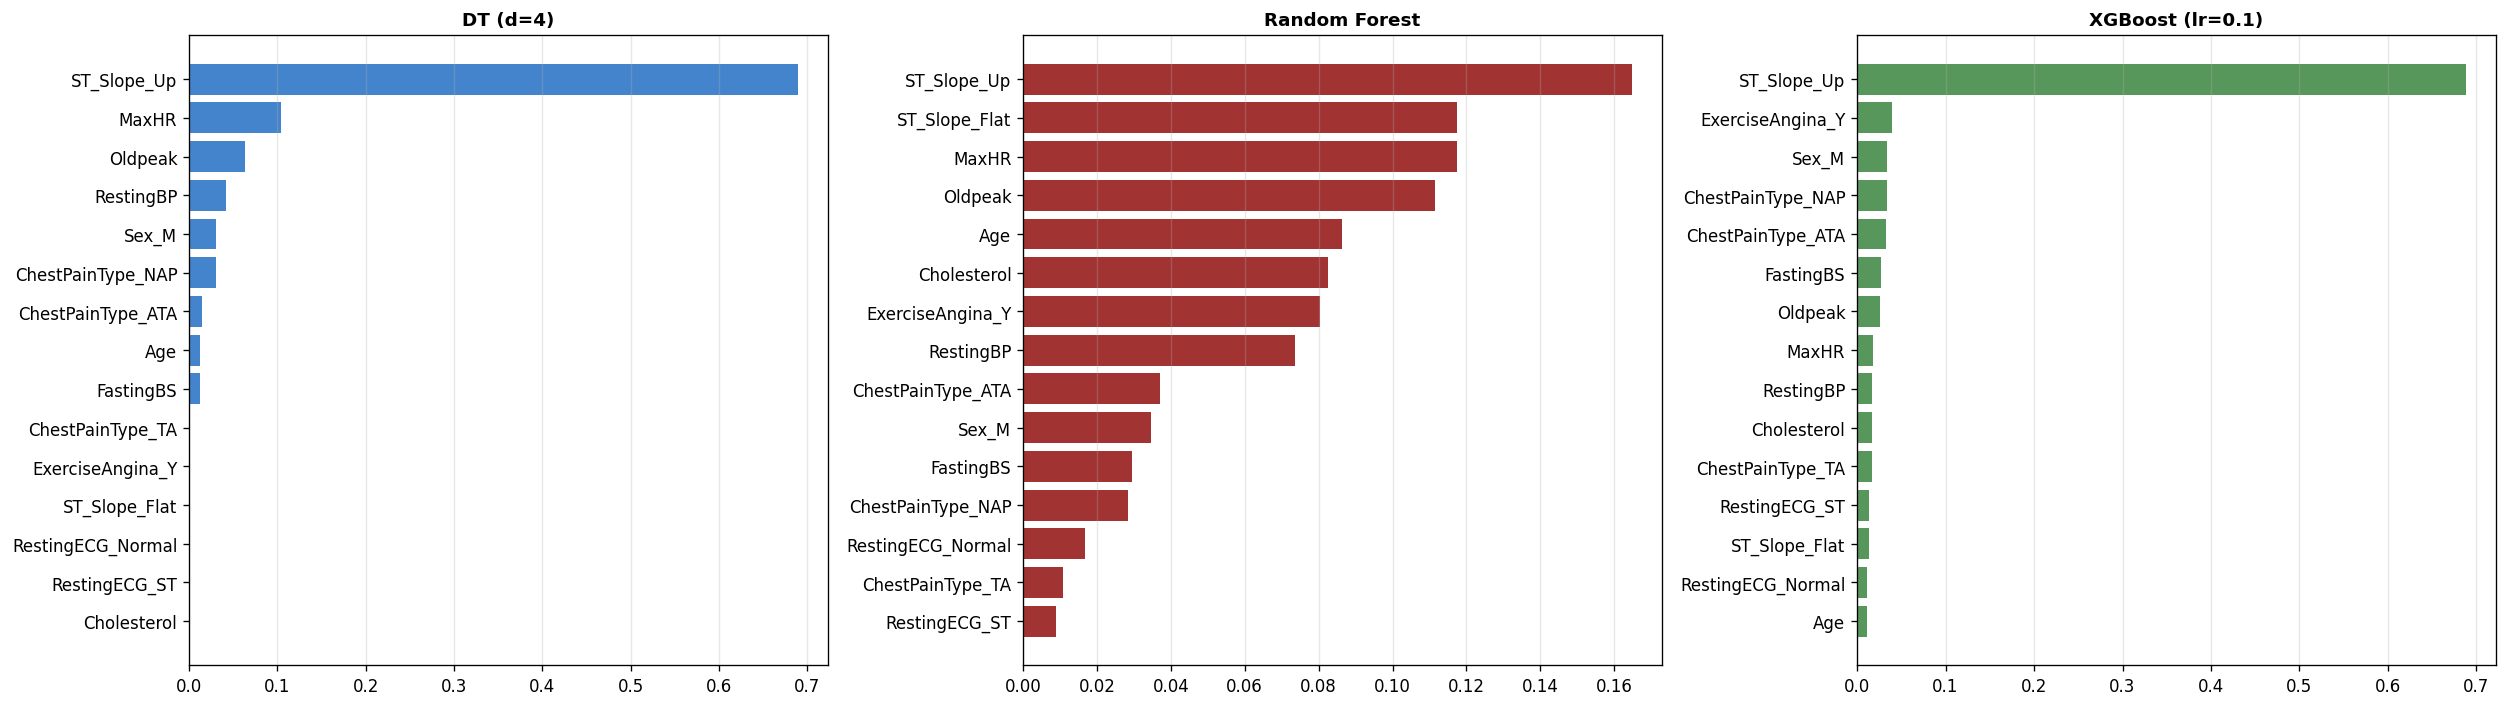

In [ ]:
# ── Feature Importance: DT vs RF vs XGBoost ─────────────────────
importances_xgb = xgb_final.feature_importances_

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, imp, title, color in zip(
    axes,
    [importances_dt, importances_rf, importances_xgb],
    [f'DT (d={best_depth})', 'Random Forest', f'XGBoost (lr={best_lr})'],
    [UPCH_BLUE, UPCH_RED, UPCH_GREEN]
):
    idx = np.argsort(imp)
    ax.barh([feature_names[i] for i in idx], imp[idx], color=color, alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
# PARTE 4 — Comparación Final
## Ejercicio 6 — ROC curves y tabla de métricas

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 6.1 — Curvas ROC

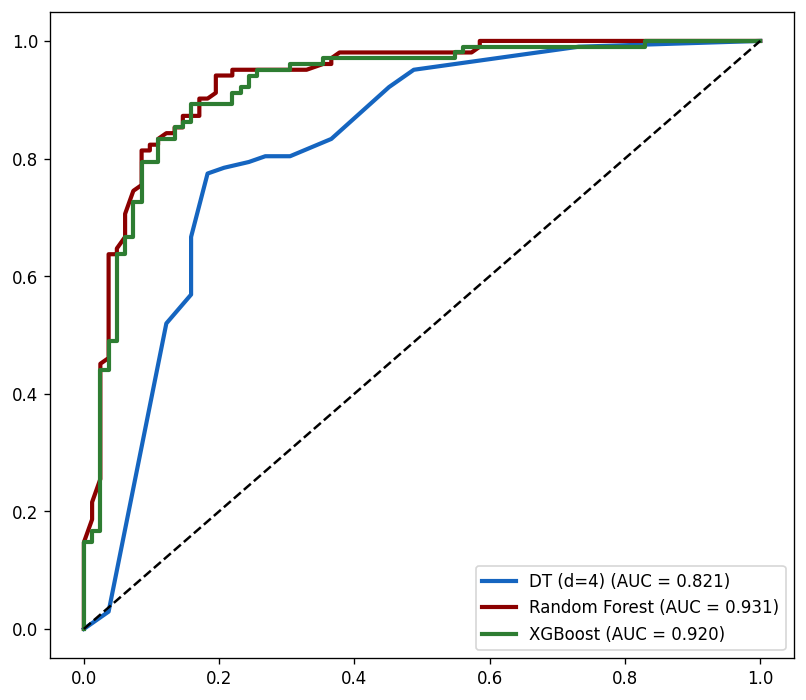

In [ ]:
# ── Curvas ROC: DT, RF, XGBoost ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for modelo, nombre, color in [
    (dt_opt,    f'DT (d={best_depth})', UPCH_BLUE),
    (rf_final,  'Random Forest',        UPCH_RED),
    (xgb_final, 'XGBoost',             UPCH_GREEN)
]:
    y_score = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f'{nombre} (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k--')
ax.legend(loc='lower right')
plt.show()

### Paso 6.2 — Tabla de métricas comparativa

In [ ]:
# ── Tabla de métricas comparativa ───────────────────────────────
print('=' * 75)
print('     RESUMEN FINAL — Challenge 4: Árboles, RF y XGBoost')
print('=' * 75)
print(f'{"Modelo":<40} {"Acc":<10} {"Rec":<10} {"Prec":<10} {"F1"}')
print('-' * 75)

resultados = [
    (f'DT (d={best_depth})', acc_dt, rec_dt, prec_dt, f1_dt),
    ('Random Forest (n=200)', acc_rf, rec_rf, prec_rf, f1_rf),
    ('XGBoost Optimizado', acc_xgb, rec_xgb, prec_xgb, f1_xgb),
]
for nombre, acc, rec, prec, f1 in resultados:
    print(f'{nombre:<40} {acc:.4f}     {rec:.4f}     {prec:.4f}     {f1:.4f}')

     RESUMEN FINAL — Challenge 4: Árboles, RF y XGBoost
Modelo                                   Acc        Rec        Prec       F1
---------------------------------------------------------------------------
DT (d=4)                                 0.7772     0.7941     0.8020     0.7980
Random Forest (n=200)                    0.8587     0.8725     0.8725     0.8725
XGBoost Optimizado                       0.8641     0.8824     0.8738     0.8780


### Paso 6.3 — Interpretación sesgo-varianza

**📝 Tu respuesta:**

Completa la tabla:

| Modelo | Sesgo | Varianza | Mecanismo de reducción |
|---|---|---|---|
| Árbol profundo | Bajo | Alto | Ninguno (tiende al overfitting) |
| Árbol prepodado / profundidad controlada | Moderado | Moderado | Pre-poda (limitación de `max_depth`) |
| Random Forest | Moderado/Bajo | Bajo | Bagging y muestreo aleatorio de variables (Feature Bagging) |
| XGBoost | Bajo | Bajo | Boosting (corrección secuencial de errores) y regularización |

**¿En qué escenario clínico usarías cada modelo? Justifica:**

- **Árbol de Decisión prepodado:** Lo usaría en un entorno de triaje rápido o consulta inicial donde la **interpretabilidad** sea crítica. Permite al médico ver una regla simple (ej: si el ST_Slope es Up, el riesgo es bajo) que puede validar visualmente en segundos.
- **Random Forest:** Ideal para análisis robustos de factores de riesgo. Al ser menos sensible a valores atípicos (outliers) que un árbol solo, es muy confiable para obtener una **importancia de variables** más estable y generalizable.
- **XGBoost:** Lo usaría en un sistema de apoyo a la decisión clínica (CDSS) de **alta precisión** en una unidad de cardiología, donde maximizar el Recall (detección de enfermos) sea la prioridad absoluta y se cuente con el poder computacional para ajustar el modelo.


---
<div style='background:#f5f5f5; padding:15px; border-left:5px solid #8B0000; border-radius:4px'>
<b>Entrega:</b> Sube tu notebook ejecutado (.ipynb con outputs) a tu carpeta de GitHub del curso.<br>
<b>Nombre del archivo:</b> <code>Challenge4_ApellidoNombreDeAmbos.ipynb</code><br>
<b>Fecha límite:</b> antes de Clase 6
</div>
